In [1]:
import pydicom
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import matplotlib.patches as patches 

ROOT = "D:/marchine_learning/Projet/medical_project/AI-Clinical-Imaging-Assistant/data/vindr-spinexr/" 
path_train_img = ROOT + "train_images/"
path_train_csv = ROOT + "annotations/train.csv"

## Explore the  the annotations files

La liste des colone Index(['study_id', 'series_id', 'image_id', 'rad_id', 'lesion_type', 'xmin',
       'ymin', 'xmax', 'ymax'],
      dtype='str')


[]

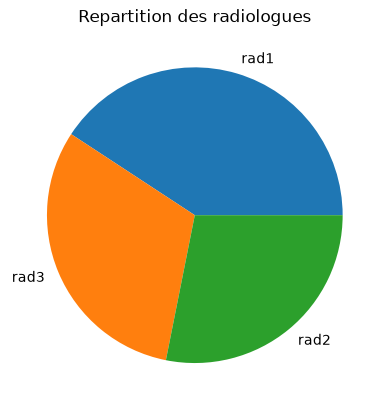

In [2]:
raw_dataframe = pd.read_csv(path_train_csv)

# Use subset of the original dataset
train_img_file = [file[:-6] for file in os.listdir(path_train_img)]
dataframe = raw_dataframe[raw_dataframe['image_id'].isin(train_img_file)].reset_index(drop=True)

print(f"La liste des colone {dataframe.columns}")
dataframe['rad_id'].value_counts().plot(kind='pie')
plt.title('Repartition des radiologues')
plt.plot()

## Handle Data as Multilabel classification

{'Osteophytes': 0.3379180151024811,
 'Other lesions': 3.7291666666666665,
 'Spondylolysthesis': 4.675373134328358,
 'Disc space narrowing': 1.970125786163522,
 'No finding': 0.28271660649819497,
 'Foraminal stenosis': 4.746212121212121,
 'Surgical implant': 5.695454545454545,
 'Vertebral collapse': 7.83125}

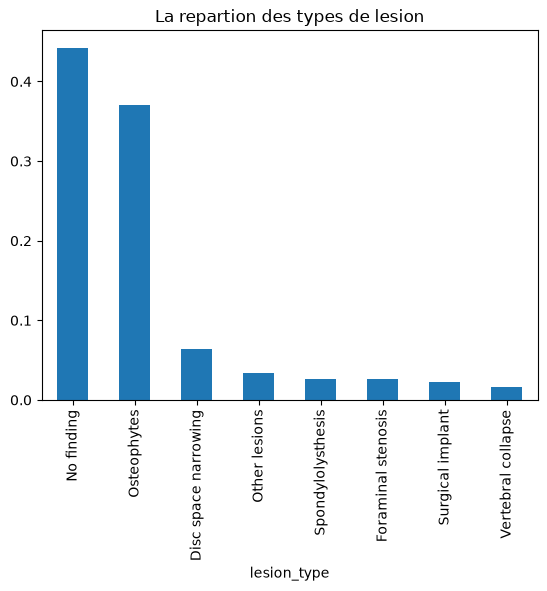

In [3]:
# Create a dataframe without doublons  
classification_data = dataframe.drop_duplicates(['image_id', 'lesion_type']).reset_index(drop=True)

classification_data['lesion_type'].value_counts(normalize=True).plot(kind='bar')
plt.title("La repartion des types de lesion")
plt.plot()

# Calculate the class weights
labels = classification_data['lesion_type']
classes = classification_data['lesion_type'].unique()

counts = labels.value_counts().reindex(classes)
weights = counts.sum() / (len(classes) * counts) # type: ignore
weights.to_dict()

In [4]:
labels = weights.keys().to_list()
classification_data['digit_label'] = classification_data['lesion_type'].apply(lambda x: [1 if label in x else 0 for label in labels])
classification_data.head(8)

,study_id,series_id,image_id,rad_id,lesion_type,xmin,ymin,xmax,ymax,digit_label
0,88ec4a2f0842407e5489b53728a1709b,c0b663cf5497398f49dd717b46debf06,1f1c5c098c35b79052596aae08ac727f,rad1,Osteophytes,712.636842,961.361404,786.587719,1011.782456,"[1, 0, 0, 0, 0, 0, 0, 0]"
1,88ec4a2f0842407e5489b53728a1709b,c0b663cf5497398f49dd717b46debf06,3bb3235634a304d102d334e962328612,rad1,Osteophytes,709.842690,1130.152047,779.990058,1192.505263,"[1, 0, 0, 0, 0, 0, 0, 0]"
2,3be2faba87a19cd35af14e6544236b50,2a7aa997478dbf3c73068680ee1a39ba,276615e32daf16ea56813ce30976817f,rad1,Osteophytes,781.152632,1389.157895,841.405263,1446.063158,"[1, 0, 0, 0, 0, 0, 0, 0]"
3,da300a32e2942e4fc7c81a1f2dab8edb,a138b6b6fd0a32eb30fc3337e73eff5a,3dc6797f2b0b709635211b7967d44bdc,rad1,Other lesions,826.660090,2031.183766,987.106539,2150.665163,"[0, 1, 0, 0, 0, 0, 0, 0]"
4,da300a32e2942e4fc7c81a1f2dab8edb,a138b6b6fd0a32eb30fc3337e73eff5a,3dc6797f2b0b709635211b7967d44bdc,rad1,Osteophytes,1285.858753,1719.572737,1367.632685,1798.941553,"[1, 0, 0, 0, 0, 0, 0, 0]"
5,da300a32e2942e4fc7c81a1f2dab8edb,a138b6b6fd0a32eb30fc3337e73eff5a,3dc6797f2b0b709635211b7967d44bdc,rad1,Spondylolysthesis,932.486471,2174.561443,1301.171928,2348.662909,"[0, 0, 1, 0, 0, 0, 0, 0]"
6,da300a32e2942e4fc7c81a1f2dab8edb,a138b6b6fd0a32eb30fc3337e73eff5a,3dc6797f2b0b709635211b7967d44bdc,rad1,Disc space narrowing,932.486471,2174.561443,1301.171928,2348.662909,"[0, 0, 0, 1, 0, 0, 0, 0]"
7,2680f4a84310da452712d13ce28e3059,04e58462ac94ac5bd60748fb7ca9ce9b,044791c201e6080236f2410499440fff,rad1,No finding,NaN,NaN,NaN,NaN,"[0, 0, 0, 0, 1, 0, 0, 0]"


In [5]:
vector = classification_data[classification_data['image_id'] == "3dc6797f2b0b709635211b7967d44bdc"]['digit_label']
np.array(vector.tolist()).max(0)

array([1, 1, 1, 1, 0, 0, 0, 0])

In [6]:
# Found the pos_weight for the dataframe
image_labels = (
    classification_data
    .groupby('image_id')['digit_label']
    .apply(lambda x: np.max(x.tolist(), axis=0))
)

image_labels = np.stack(image_labels.values)
positive_counts = image_labels.sum(axis=0)
negative_counts = image_labels.shape[0] - positive_counts
pos_weight = negative_counts / positive_counts

pos_weight

array([ 1.33225458, 24.73809524, 31.26865672, 12.59748428,  0.95126354,
       31.75757576, 38.30909091, 53.05      ])

## Go deeper to metadata and vizualize the images

In [7]:
dcms = [pydicom.dcmread(path_train_img + train_img_file[i] + '.dicom') for i in range(len(train_img_file)// 2)]

In [ ]:
HighBit = []
BitsStored = []
BitsAllocated = []
PatientSex = []
PixelRepresentation = []
PhotometricInterpretation = []

for dcm in dcms:
    HighBit.append(dcm['HighBit'].value)
    BitsStored.append(dcm['BitsStored'].value)
    BitsAllocated.append(dcm['BitsAllocated'].value)
    PatientSex.append(dcm['PatientSex'].value)
    PixelRepresentation.append(dcm['PixelRepresentation'].value)
    PhotometricInterpretation.append(dcm['PhotometricInterpretation'].value)

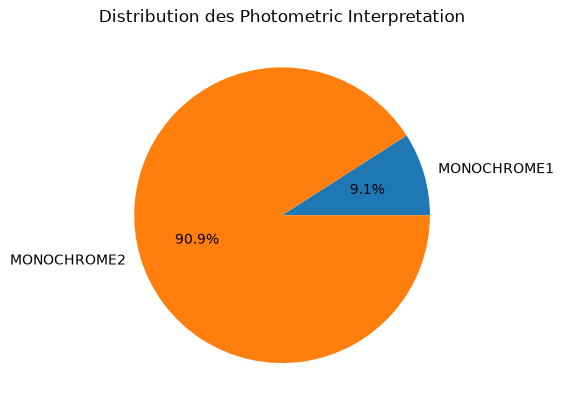

In [18]:
from collections import Counter
counts = Counter(PhotometricInterpretation)
plt.pie(
    counts.values(),
    labels=counts.keys(),
    autopct="%1.1f%%"
)

plt.title("Distribution des Photometric Interpretation")
plt.show()

In [8]:
mean_pixels = []
max_pixels = []
for dcm in dcms[:500]:
    mean_pixels.append(np.mean(dcm.pixel_array))
    max_pixels.append(np.max(dcm.pixel_array))

std_pixel_representation = 0.0 et la moyenne = 0.0


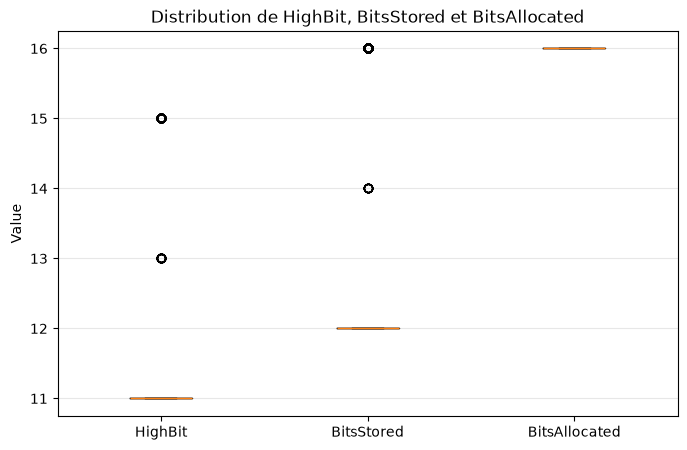

In [9]:
print(f"std_pixel_representation = {np.std(PixelRepresentation)} et la moyenne = {np.mean(PixelRepresentation)}")
plt.figure(figsize=(8, 5))

plt.boxplot(
    [HighBit, BitsStored, BitsAllocated],
    tick_labels=['HighBit', 'BitsStored', 'BitsAllocated']
)

plt.title("Distribution de HighBit, BitsStored et BitsAllocated")
plt.ylabel("Value")
plt.grid(axis='y', alpha=0.3)
plt.show()

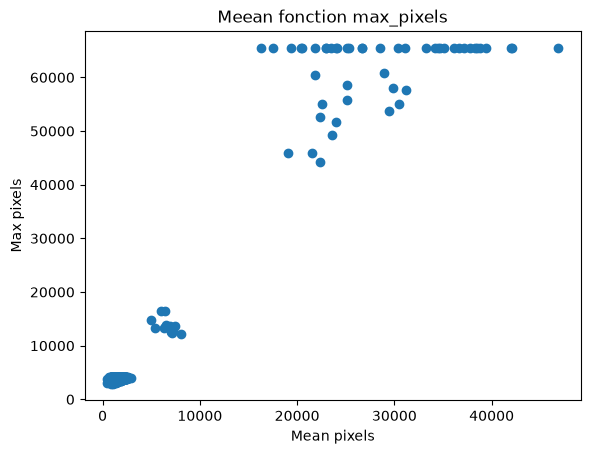

In [10]:
fig, ax = plt.subplots()
ax.scatter(mean_pixels, max_pixels)

ax.set_title("Meean fonction max_pixels")
ax.set_xlabel("Mean pixels")
ax.set_ylabel("Max pixels")

plt.show()

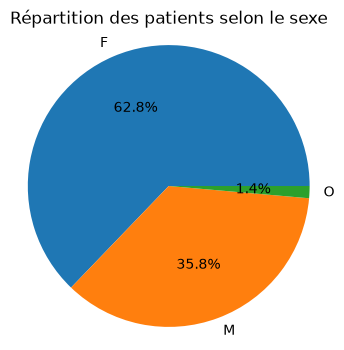

In [11]:
values, count = np.unique(PatientSex, return_counts=True)

plt.figure(figsize=(4,4))
plt.pie(count, labels=values, autopct='%1.1f%%')

plt.title("Répartition des patients selon le sexe")
plt.axis('equal')  # Pour que le camembert soit circulaire

plt.show()

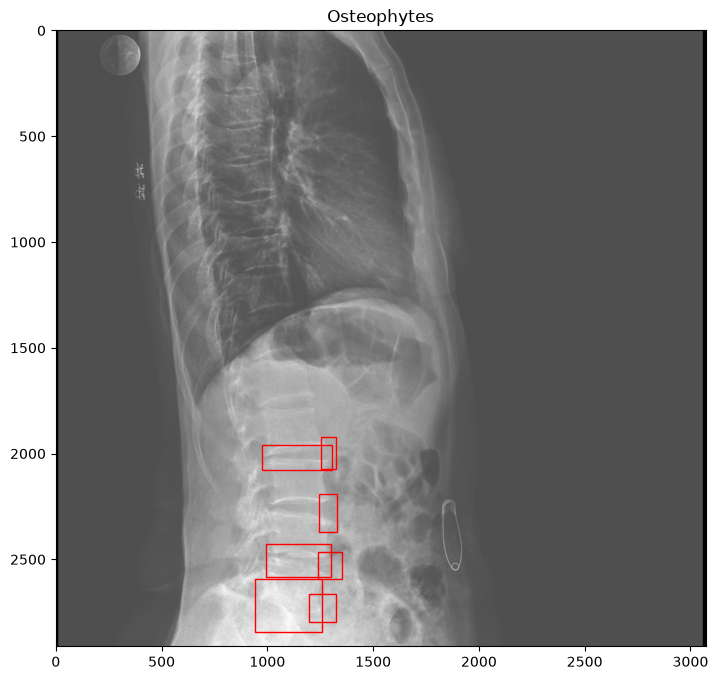

In [12]:
index_show = 15
fig, ax = plt.subplots(figsize=(15, 8))
ax.imshow(dcms[index_show].pixel_array, cmap='gray')
ax.set_title(dataframe[dataframe['image_id'] == train_img_file[index_show]]['lesion_type'].unique()[0])
boxes_frame = dataframe[dataframe['image_id'] == train_img_file[index_show]]
for i in range(len(boxes_frame)):
    xmin, ymin, xmax, ymax = boxes_frame[['xmin', 'ymin', 'xmax', 'ymax']].iloc[i]
    rect = patches.Rectangle((xmin, ymin), xmax- xmin, ymax - ymin, linewidth=1,
                            edgecolor='red', facecolor='none')
    ax.add_patch(rect)
plt.show()